In [1]:
from importlib.metadata import version
print("langchain version: ", version("langchain"))
print("langgraph version: ", version("langgraph"))
print("langchain-openai version: ", version("langchain-openai"))
print("langchain-core version: ", version("langchain-core"))
print("langchain_community version: ", version("langchain_community"))
print("langchain_mcp_adapters version: ", version("langchain_mcp_adapters"))
print("tavily-python version: ", version("tavily-python"))

langchain version:  1.3.17
langgraph version:  1.2.11
langchain-openai version:  1.6.0
langchain-core version:  1.6.0
langchain_community version:  0.4.2
langchain_mcp_adapters version:  0.3.2
tavily-python version:  0.8.0


In [2]:
import os
from dotenv import load_dotenv
import openai
load_dotenv()

True

2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'draft' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_summarizer' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_main' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'researcher_compressor' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'red_team' with handle 'deepseek-v4-flash' (timeout=600)
2026-09-11 20:22:37 [INFO] deep_research.llm: Selected cognition backend 'openai' fo

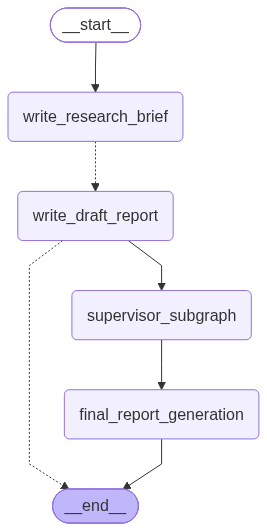

In [3]:
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from deep_research.agent_builder import deep_researcher_builder
import warnings

warnings.filterwarnings("ignore")
checkpointer = InMemorySaver()
full_agent = deep_researcher_builder.compile(checkpointer=checkpointer)
display(Image(full_agent.get_graph(xray=True).draw_mermaid_png()))


In [4]:
from deep_research.llm import get_chat_model
m = get_chat_model("writer")
print(m.openai_api_base)   # 应打印 https://api.deepseek.com

m = get_chat_model("writer")
print(m.openai_api_base)   # https://api.deepseek.com
print(m.extra_body)        # {'thinking': {'type': 'disabled'}}

2026-09-11 20:22:39 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'deepseek-v4-flash' (timeout=600)
https://api.deepseek.com
2026-09-11 20:22:39 [INFO] deep_research.llm: Selected cognition backend 'openai' for role 'writer' with handle 'deepseek-v4-flash' (timeout=600)
https://api.deepseek.com
{'thinking': {'type': 'disabled'}}


In [5]:
# take 10 ~ 20 minutes to finish the task.
from langchain_core.messages import HumanMessage
thread = {"configurable": {"thread_id": "1", "recursion_limit": 50}}
result = await full_agent.ainvoke({"messages": [HumanMessage(content="给我研究一下现在游戏《异环》的账号选购方案，预算1000元")]}, config=thread)

2026-09-11 20:30:11 [INFO] deep_research.agents.draft_agent: [DRAFT] requesting research brief
2026-09-11 20:30:16 [INFO] deep_research.agents.draft_agent: [DRAFT] requesting draft report (this may take a while for long reports)
2026-09-11 20:30:28 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=0, messages=2)
2026-09-11 20:30:31 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-09-11 20:30:31 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-09-11 20:30:31 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=1, messages=4)
2026-09-11 20:30:37 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=3
2026-09-11 20:30:37 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=0 conduct=3 refine=0
2026-09-11 20:30:38 [INFO] deep_research.ag

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ProtocolError('Connection aborted.', TimeoutError('The write operation timed out')))"))
Content-Length: 2081314
API Key: lsv2_********************************************e7trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09075-e08e-7053-8bf1-188b139553ea; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09075-e08c-7f93-9951-9122855f1cff; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09076-4a54-7b61-898a-050e7227603e; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09076-4a55-7042-9853-126575f49cc6; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09076-4a55-7042-9853-126575f49cc6; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a09076-53db-7af2-8

2026-09-11 20:37:00 [INFO] deep_research.agents.research_agent: llm_call produced response tool_calls=False num_tool_calls=0
2026-09-11 20:37:00 [INFO] deep_research.agents.research_agent: should_continue decision=compress_research (has_tool_calls=False)
2026-09-11 20:37:00 [INFO] deep_research.agents.research_agent: compress_research invoked with 24 messages
2026-09-11 20:38:07 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=6, messages=17)
2026-09-11 20:38:12 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-09-11 20:38:12 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor_tools executing think=1 conduct=0 refine=0
2026-09-11 20:38:12 [INFO] deep_research.agents.supervisor: [SUPERVISOR] supervisor invoked (iteration=7, messages=19)
2026-09-11 20:38:12 [INFO] deep_research.agents.supervisor: supervisor model produced tool_calls=True num_tool_calls=1
2026-09-11 20:38:12 [INFO] deep_res

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ProtocolError('Connection aborted.', TimeoutError('The write operation timed out')))"))
Content-Length: 2825077
API Key: lsv2_********************************************e7trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-1840-73e3-a958-c7928a38ca4e; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-183d-78a2-9b1c-276b83e8eb9c; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2765-74b1-9cb2-c82c7ec79620; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2768-7133-90e9-c5e149944ecb; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2768-7133-90e9-c5e149944ecb; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2765-74b1-9

Failed to send compressed multipart ingest: Connection error caused failure to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. Please confirm your internet connection. ConnectionError(MaxRetryError("HTTPSConnectionPool(host='api.smith.langchain.com', port=443): Max retries exceeded with url: /runs/multipart (Caused by ProtocolError('Connection aborted.', TimeoutError('The write operation timed out')))"))
Content-Length: 9461585
API Key: lsv2_********************************************e7trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2bbc-7c73-b9cc-c689cbf94664; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-2bbb-7473-bc62-98f94616d8e6; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-8de5-7041-91d4-69a52931fa2e; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-8de6-7ed0-8818-4180a9442ec3; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-8de6-7ed0-8818-4180a9442ec3; trace=01a09072-665d-7f30-9c01-68c2db6a4ce9,id=01a0907d-9afb-7812-a

In [6]:
from rich.console import Console
from rich.markdown import Markdown

# 创建控制台对象
console = Console()
console.print(Markdown(result["final_report"]))

《异环》（Neverness to Everness / NTE）账号选购深度研究报告                            

一、核心事实确认：游戏运营状态与账号市场背景                                                                       

1.1 公测时间与当前运营阶段                                                                                         

《异环》（英语：Neverness to Everness，简称 NTE）由完美世界旗下 Hotta                                              
Studio（幻塔工作室）自主研发，采用虚幻引擎5打造，是一款超自然都市开放世界RPG [1][2]。                              

正式公测时间为2026年4月23日（中国大陆）与2026年4月29日（国际服及台港澳服）                                         
[1][2]。完美世界于2026年3月9日在投资者互动平台确认："《异环》国服全平台公测正式定档2026年4月23日"                  
[3]。2025年实际发生的是测试阶段——2025年5月21日获得游戏版号，2025年6月26日开启"收容测试"（二测），2025年12月23日开启
"共存测试"（三测）招募 [1][2]。                                                                                    

截至2026年9月，游戏处于公测后的版本迭代期，已更新至1.3版本「雾中朔望星回」（2026年8月19日更新）[4][5]。商业表现方面
，全球首日流水突破1亿元人民币，截至2026年8月18日全球累计流水突破20亿元人民币 [6][7]。                              

这一时间线对账号选购具有决定性意义：游戏公测至今仅约5个月，账号市场仍处于早期阶段，价格体系尚未成熟，整体价格偏低。

1.2 区服划分                                                                                                       

《异环》的服务器划分较为复杂，选购账号时需明确区分 [1][8][9]：                                                     

                                                                                                                   
 区服      运营主体             登录账号                                 下载渠道                                  
 ───────────────────────────────────────────────────────────────────────────────────────────────────────────────── 
 国服官服  完美世界             完美通行证                               官网                                      
                                                                         yh.wanmei.com、TapTap、好游快爆、AppStor… 
 国服B服   B站渠道              bilibili账号                             B站客户端/游戏中心                        
 国际服    Perfect World Games  PWG账号、Facebook、Google、Apple、邮箱…  官网 nte.perfectworld.com                 
 台港澳服  艾玩天地             手机号、Facebook、Google、Apple、PSN     nte.iwplay.com.tw                         
 PS5主机   按PSN账号地区决定    PSN账号                                  PS商店                                    
                                                                                                                   

国际服进一步细分为 Asia、America、Europe、SEA 四个服务器，各服务器相互独立，游戏数据不互通                         
[8]。中国大陆版、国际版与台港澳版数据资料同样不互通 [1]。                                                          

关于官服与B服是否互通：根据游侠网2026年4月28日发布的攻略文章，《异环》只有1个官方服务器，B服/B站登录属于官服体系， 
与完美官服互通（可加好友、联机、串门）；真正独立不互通的是华为、OPPO、vivo、小米、应用宝等手机厂商商店下载的渠道服 
[9]。B站官方公测FAQ的表述也印证了这一点："《异环》仅有一个官方服务器，鉴定师使用bilibili账号即可登录" [10]。       

1.3 账号绑定机制                                                                                                   

根据《异环》官方账号绑定教学（台港澳服）与国际服FAQ，账号支持以下绑定方式 [11][8]：                                

 • 手机号码：通过短信临时密码机制绑定，可用于登录                                                                  
 • 邮箱：部分平台支持邮箱登录                                                                                      
 • 第三方账号：Facebook、Google、Apple、PSN                                                                        
 • B站账号（国服B服）                                                                                              

重要限制：国际服FAQ明确指出"不同第三方授权账号注册及登录的账号数据相互独立、不互通"                                
[8]。国服账号根据中国大陆网络游戏管理规定必须完成实名认证 [12]。                                                   

PS5平台特殊规则：根据NTE官方PS5                                                                                    
FAQ，PWG邮箱账号一旦关联至游戏账号，不可更改或解绑；PSN账号可以解绑，但每个PSN账号仅能解绑一次，且解绑前必须先为游 
戏账号关联PWG邮箱账号 [13]。                                                                                       

1.4 官方对账号交易的态度                                                                                           

《完美世界游戏用户协议》明确禁止账号买卖，这是选购账号时最大的政策风险 [14]：                                      

▌ "在无充足相反证据证明的情况下，用户账号使用权属于初始注册人。在没有经过完美世界同意并登记的情况下，用户不得对账
▌ 号使用权进行买卖、赠与、交换、继承或其他形式的交易。"                  

In [8]:
from datetime import date
path = f"./output_report_{date.today().strftime('%Y-%m-%d')}.md"
with open(path, "w") as fd:
    fd.write(result["final_report"])
print(f"调研报告已保存在 {path}。")

调研报告已保存在 ./output_report_2026-09-11.md。


In [9]:
print(result["final_report"])

# 《异环》（Neverness to Everness / NTE）账号选购深度研究报告

## 一、核心事实确认：游戏运营状态与账号市场背景

### 1.1 公测时间与当前运营阶段

《异环》（英语：Neverness to Everness，简称 NTE）由完美世界旗下 Hotta Studio（幻塔工作室）自主研发，采用虚幻引擎5打造，是一款超自然都市开放世界RPG [1][2]。

**正式公测时间为2026年4月23日（中国大陆）与2026年4月29日（国际服及台港澳服）** [1][2]。完美世界于2026年3月9日在投资者互动平台确认："《异环》国服全平台公测正式定档2026年4月23日" [3]。2025年实际发生的是测试阶段——2025年5月21日获得游戏版号，2025年6月26日开启"收容测试"（二测），2025年12月23日开启"共存测试"（三测）招募 [1][2]。

截至2026年9月，游戏处于公测后的版本迭代期，已更新至**1.3版本「雾中朔望星回」**（2026年8月19日更新）[4][5]。商业表现方面，全球首日流水突破1亿元人民币，截至2026年8月18日全球累计流水突破20亿元人民币 [6][7]。

这一时间线对账号选购具有决定性意义：**游戏公测至今仅约5个月，账号市场仍处于早期阶段，价格体系尚未成熟，整体价格偏低**。

### 1.2 区服划分

《异环》的服务器划分较为复杂，选购账号时需明确区分 [1][8][9]：

| 区服 | 运营主体 | 登录账号 | 下载渠道 |
|------|----------|----------|----------|
| **国服官服** | 完美世界 | 完美通行证 | 官网 yh.wanmei.com、TapTap、好游快爆、AppStore、PS5 |
| **国服B服** | B站渠道 | bilibili账号 | B站客户端/游戏中心 |
| **国际服** | Perfect World Games | PWG账号、Facebook、Google、Apple、邮箱、PSN | 官网 nte.perfectworld.com |
| **台港澳服** | 艾玩天地 | 手机号、Facebook、Google、Apple、PSN | nte.iwplay.com.tw 